#KNN (*K-Nearest Neighbors*)

KNN es un algoritmo de aprendizaje automático supervisado que clasifica o predice datos basándose en la mayoría de sus vecinos más cercanos. Funciona bajo la premisa de que los puntos similares se encuentran cerca unos de otros, y puede usarse para tareas de clasificación (votación mayoritaria entre vecinos) y regresión (promedio de los valores de los vecinos).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [ ]:
#Cargamos el dataset

iris = load_iris()
data = pd.DataFrame(data = np.c_[iris['data'], iris['target']],
                    columns = iris['feature_names'] + ['target'])
data
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [ ]:
# Separamos en X e y los datos a usar en el modelo

X = data[['sepal length (cm)', 'sepal width (cm)']]
y = data.target

X.head()
#y.head()

#Cuantas etiquetas tiene el y o target?

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


Luego, como aprendimos, vamos a separar el dataset en conjuntos de entrenamiento `X_train, y_train` y de testeo `X_test,y_test` usando la función `train_test_split` de Scikit-Learn.

Esto lo hacemos para separar parte de los datos `X_test, y_test` con los cuales **no vamos a entrenar el modelo, sino que vamos a usarlos únicamente para evaluar su desempeño**.

2. Separa `X` e `y`, tomando en las variables `X_train, y_train` un 80% para entrenamiento y en las variables `X_test,y_test` un 20% para evaluación.
Puedes fijar el `random_state`y agregar .

In [ ]:
# Hacemos el train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

3. Crea un modelo de vecino más cercanos y entrénalo sobre el conjunto de Train.

In [ ]:
#Generamos el modelo KNN
from sklearn.neighbors import KNeighborsClassifier

clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(X_train, y_train)


KNeighborsClassifier()

4. Predice las etiquetas sobre el conjunto de Train y sobre el conjunto de Test.

In [ ]:
# Predecimos el target, tanto del train como del test
y_train_pred = clf_knn.predict(X_train)
y_test_pred = clf_knn.predict(X_test)

5. Evalúa el desempeño del modelo usando la función `accuracy_score` y la matriz de confusión sobre ambos conjuntos (Train y Test).

In [ ]:
#Observamos como funcionó el modelo
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

print(confusion_matrix(y_train, y_train_pred))
print(confusion_matrix(y_test, y_test_pred))

# Comaparamos con las etiquetas reales
accuracy_test = accuracy_score(y_test_pred,y_test)
accuracy_train = accuracy_score(y_train_pred,y_train)
print(accuracy_test)
print(accuracy_train)

[[40  0  0]
 [ 0 28 12]
 [ 1  5 34]]
[[10  0  0]
 [ 0  6  4]
 [ 0  3  7]]
0.7666666666666667
0.85


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        10
         1.0       0.67      0.60      0.63        10
         2.0       0.64      0.70      0.67        10

    accuracy                           0.77        30
   macro avg       0.77      0.77      0.77        30
weighted avg       0.77      0.77      0.77        30



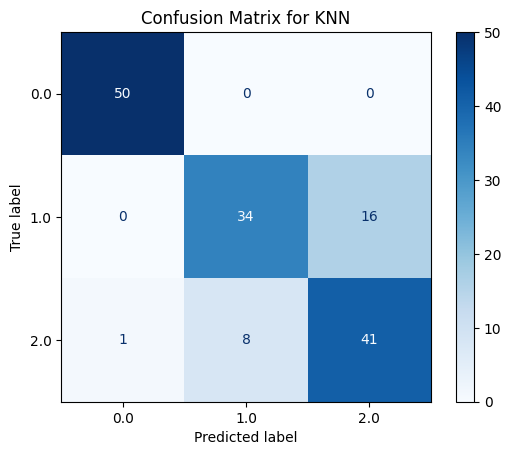

In [ ]:
#Graficamos para hacerlo mas visual
from sklearn.metrics import ConfusionMatrixDisplay

print(classification_report(y_test, y_test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf_knn, X, y,
                                             cmap=plt.cm.Blues)
disp.ax_.set_title("Confusion Matrix for KNN")
plt.show()

## Puedo probar diferentes valores K y ver el error que genera el modelo, seleccionando el mejor valor.

In [ ]:
# Pruebo que K da menor error en el modelo

error = []

# Calculo del error para valores de K entre 1 y 40
for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error medio')

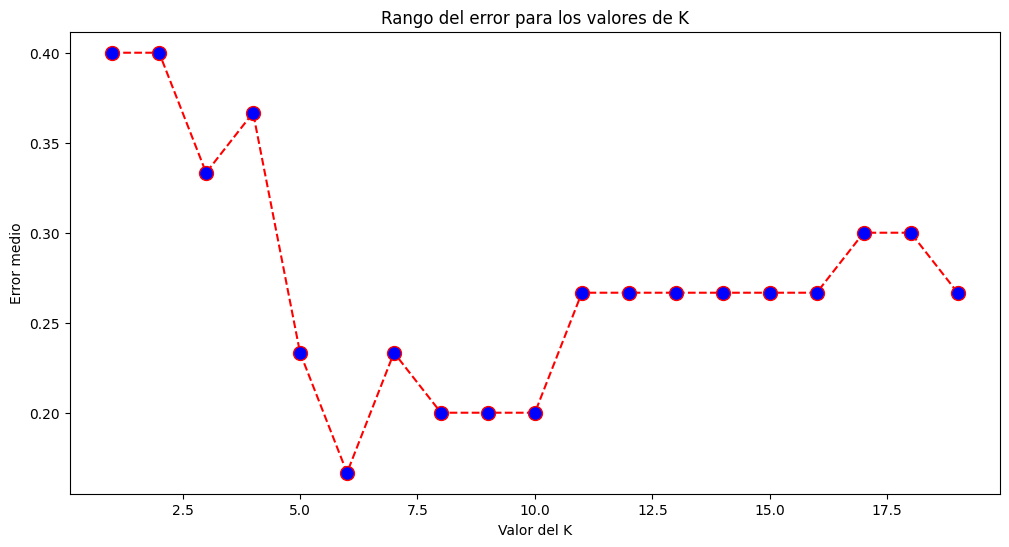

In [ ]:
#Grafico el error con los diferentes valores de K

plt.figure(figsize=(12, 6))
plt.plot(range(1, 20), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Rango del error para los valores de K')
plt.xlabel('Valor del K')
plt.ylabel('Error medio')

Probemos diferentes valores de K pero con un bucle como 'for' para detectar el valor de K mas optimo y evaluar el mejor modelo. Para ello, debemos evaluar la exactitud del modelo en el set de train y test para distintos valores del parámetro `n_neighbors`. Vamos entonces a repetir el esquema de: **definir, entrenar y predecir** en un loop `for` que recorre una lista con distintos valores de vecinos.

**Ejercicio**: Trabaja en el siguiente bloque de codigo, de manera de completar con valores las listas `lista_accuracy_train` y `lista_accuracy_test`.

In [ ]:
# Definimos las listas vacias para los valores de accuracy deseados
lista_accuracy_train = []
lista_accuracy_test = []

# Definimos la lista de valores de k que vamos a explorar
k_vecinos = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,50]

# Generamos un loop sobre los distintos valores de k
for k in k_vecinos:

    # Vamos a repetir el siguiente bloque de código

    # Definir el modelo con el valor de vecinos deseado
    clf = KNeighborsClassifier(n_neighbors = k)

    # Entrenar el modelo
    clf.fit(X_train, y_train)

    # Predecir y evaluar sobre el set de entrenamiento
    y_train_pred = clf.predict(X_train)
    train_acc = accuracy_score(y_train_pred,y_train)

    # Predecir y evaluar sobre el set de evaluación
    y_test_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test_pred,y_test)

    # Agregar la información a las listas
    lista_accuracy_train.append(train_acc)
    lista_accuracy_test.append(test_acc)

Realizamos un gráfico que muestre la curvas de accuracy en el set de entrenamiento (`lista_accuracy_train`) y accuracy en el set de testeo (`lista_accuracy_test`) en función del numero de vecinos (`N° K vecinos`).

Text(0, 0.5, 'exactitud')

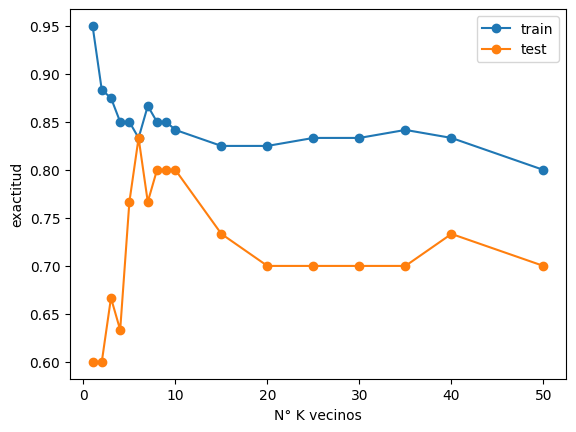

In [ ]:
#completar
plt.plot(k_vecinos, lista_accuracy_train,'o-',label='train')
plt.plot(k_vecinos, lista_accuracy_test,'o-',label='test')
plt.legend()
plt.xlabel('N° K vecinos')
plt.ylabel('exactitud')

Probemos ahora con las otras dos variables del dataset (petal) y observemos que sucede. Vamos a graficar finalmente en un grafico con color como quedan los diferentes grupos definidos de acuerdo al modelo con distintos valores de K

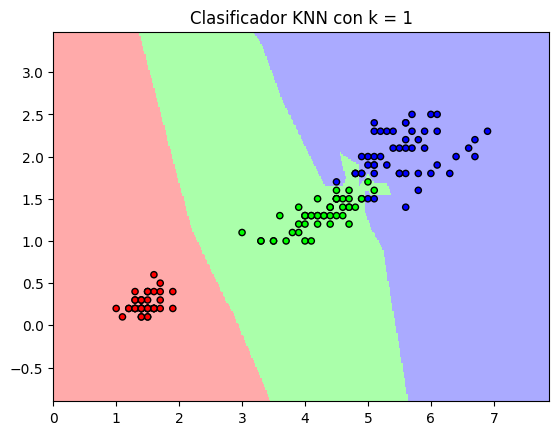

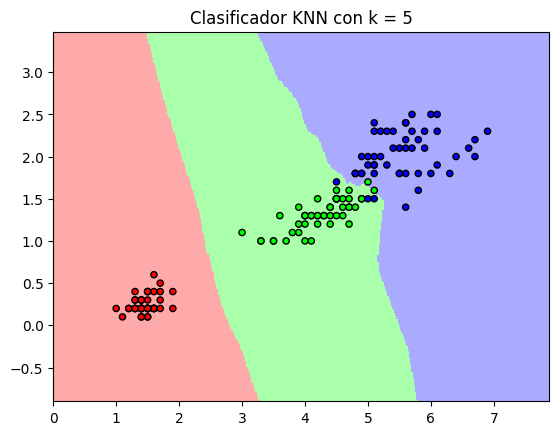

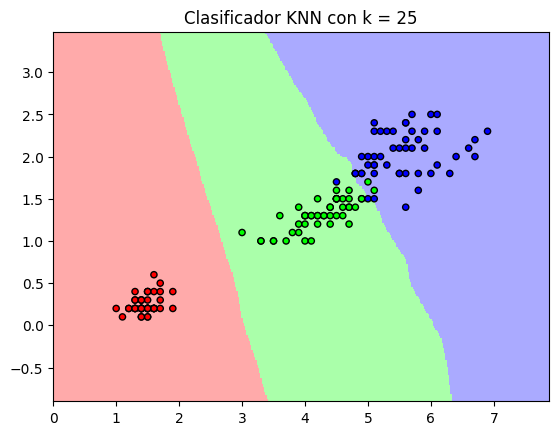

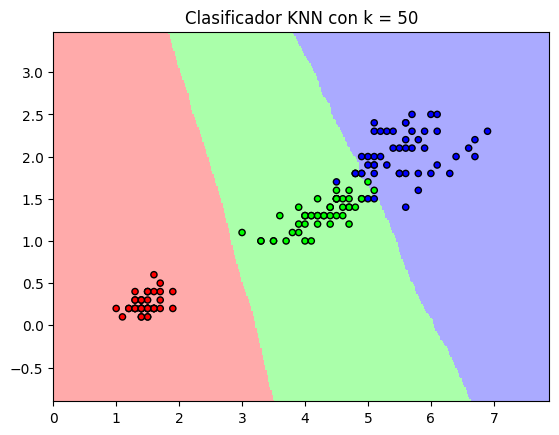

In [ ]:
from matplotlib.colors import ListedColormap

Xp = data[['petal length (cm)', 'petal width (cm)']].values
yp = data.target
h = .02  #tamaño de paso en la malla

# Crear grafico/mapas con color
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

for k in [1,5,25,50]:

    # Creamos una instancia del clasificador de vecinos y ajustamos los datos..
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(Xp, yp)

    # Traza el límite de decisión. Para ello, asignaremos un color a cada uno.
    x_min, x_max = Xp[:, 0].min() - 1, Xp[:, 0].max() + 1
    y_min, y_max = Xp[:, 1].min() - 1, Xp[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    #Coloca el resultado en un gráfico de color.
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    #Traza también los puntos de entrenamiento
    plt.scatter(Xp[:, 0], Xp[:, 1], c=y, cmap=cmap_bold,
                edgecolor='k', s=20)

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Clasificador KNN con k = %i"% (k))

# 2. Dataset Titanic

Vamos a trabajar con el dataset del Titanic. La consigna consiste en:

1. Generar un KNN para este dataset.
1. Encontra el mejor K para el modelo kNN. No te olvides de agregar un `train_test_split`, predecir sobre `X_train` y `X_test` y evaluar el desempeño de los modelos sobre esos conjuntos.
1. Evalua la exactitud del modelo con las metricas vistas en la clase anterior.

In [ ]:
# Montamos el drive antes de cargar el dataset 'titanic'. El dataset lo encontras en el campus coo un archivo .csv
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargamos los datos
titanic = pd.read_csv('/content/drive/MyDrive/......ds_12_titanic.csv')
data_t = pd.DataFrame(data = titanic)
data_t.head()

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,0,22.0,1,0
1,1,1,1,38.0,1,0
2,1,3,1,26.0,0,0
3,1,1,1,35.0,1,0
4,0,3,0,35.0,0,0


In [ ]:
# Separamos en una nueva X e y los datos a usar con el modelo
X_ = data_t[['Sex', 'Age', 'Pclass','SibSp','Parch']]
y_ = data_t.Survived #Survived es nuestro target

X_.head()

,Sex,Age,Pclass,SibSp,Parch
0,0,22.0,3,1,0
1,1,38.0,1,1,0
2,1,26.0,3,0,0
3,1,35.0,1,1,0
4,0,35.0,3,0,0


In [ ]:
# Hacemos el train test split
from sklearn.model_selection import train_test_split
X_train_, X_test_, y_train_, y_test_ = train_test_split(X_, y_, test_size=0.20, random_state=42)

In [ ]:
# Generamos el modelo
from sklearn.neighbors import KNeighborsClassifier

clf_knn_ = KNeighborsClassifier(n_neighbors=5)
clf_knn_.fit(X_train_, y_train_)

KNeighborsClassifier()

In [ ]:
# Predecimos
y_train_pred_ = clf_knn_.predict(X_train_)
y_test_pred_ = clf_knn_.predict(X_test_)

[[300  37]
 [ 66 168]]
[[74 13]
 [25 31]]
0.7342657342657343
0.819614711033275
              precision    recall  f1-score   support

           0       0.75      0.85      0.80        87
           1       0.70      0.55      0.62        56

    accuracy                           0.73       143
   macro avg       0.73      0.70      0.71       143
weighted avg       0.73      0.73      0.73       143



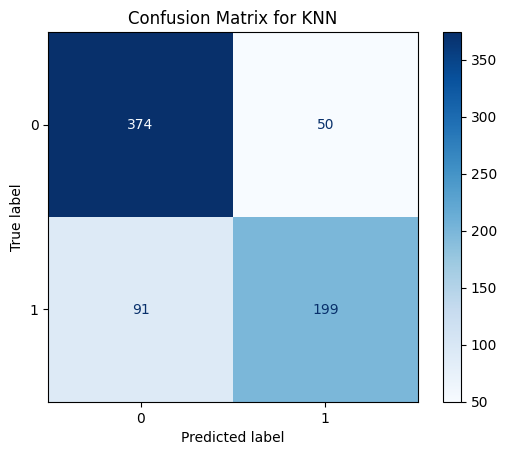

In [ ]:
# Observamos como funcionó el modelo
from sklearn.metrics import accuracy_score

print(confusion_matrix(y_train_, y_train_pred_))
print(confusion_matrix(y_test_, y_test_pred_))

# Comaparamos con las etiquetas reales
accuracy_test_ = accuracy_score(y_test_pred_, y_test_)
accuracy_train_ = accuracy_score(y_train_pred_, y_train_)
print(accuracy_test_)
print(accuracy_train_)

print(classification_report(y_test_, y_test_pred_))

#Graficamos
disp = ConfusionMatrixDisplay.from_estimator(clf_knn_, X_, y_,cmap=plt.cm.Blues)
disp.ax_.set_title("Confusion Matrix for KNN")
plt.show()

In [ ]:
# Definimos las listas vacias para los valores de accuracy deseados
lista_accuracy_train_ = []
lista_accuracy_test_ = []

# Definimos la lista de valores de k que vamos a explorar
k_vecinos_ = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,50]

# Generamos un loop sobre los distintos valores de k
for k in k_vecinos_:

    # Vamos a repetir el siguiente bloque de código

    # Definir el modelo con el valor de vecinos deseado
    clf_ = KNeighborsClassifier(n_neighbors = k)

    # Entrenar el modelo
    clf_.fit(X_train_, y_train_)

    # Predecir y evaluar sobre el set de entrenamiento
    y_train_pred_ = clf_.predict(X_train_)
    train_acc_ = accuracy_score(y_train_pred_, y_train_)

    # Predecir y evaluar sobre el set de evaluación
    y_test_pred_ = clf_.predict(X_test_)
    test_acc_ = accuracy_score(y_test_pred_, y_test_)

    # Agregar la información a las listas
    lista_accuracy_train_.append(train_acc_)
    lista_accuracy_test_.append(test_acc_)

Text(0, 0.5, 'exactitud')

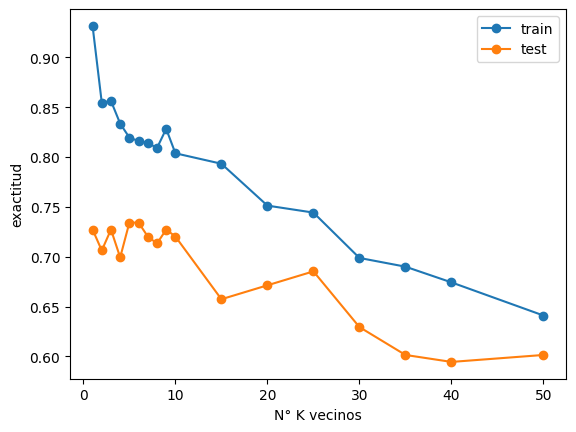

In [ ]:
# Graficamos
plt.plot(k_vecinos_, lista_accuracy_train_, 'o-', label='train')
plt.plot(k_vecinos_, lista_accuracy_test_, 'o-', label='test')
plt.legend()
plt.xlabel('N° K vecinos')
plt.ylabel('exactitud')